<a href="https://colab.research.google.com/github/Aravindr017/CNN_ModelBuilding_CIFAR-100_dataset/blob/main/Model/ComputerVision_cifar_100(dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [58]:
import tensorflow as tf
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle


from sklearn.model_selection import train_test_split


# Reading Data

In [59]:

dataset_path = "/content/drive/MyDrive/ICT - Ai Ml/Deep Learning/Convolutional Neural Network/Images/cifar-100"

print(os.listdir(dataset_path))

['meta', 'file.txt', 'test', 'train']


In [60]:
IMG_SIZE = 32          # Custom CNN input size (native CIFAR-100 resolution -> fastest, no upscaling)
VGG_IMG_SIZE = 32      # VGG16 input size. NOTE: VGG16 was designed for 224x224 images and has 5
                       # pooling stages, so at 32x32 its feature map collapses to 1x1 before the
                       # classifier head -> expect limited accuracy from VGG16 at this size no matter
                       # what. Raise this (e.g. 96) if you want VGG16 to have a fair chance.
BATCH_SIZE = 128
IMAGES_PER_CLASS = 300  # was 100 -> too little signal for 100 classes. Max available is 600/class
                        # (500 train + 100 test combined). Raise toward 600 if training time allows.

# ==========================
# Dataset Path
# ==========================
dataset_path = "/content/drive/MyDrive/ICT - Ai Ml/Deep Learning/Convolutional Neural Network/Images/cifar-100"

# ==========================
# Function to Load CIFAR-100 File
# ==========================
def load_file(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f, encoding="bytes")

    images = data[b"data"]
    labels = data[b"fine_labels"]

    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return images, np.array(labels).reshape(-1, 1)

def load_meta_file(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f, encoding="bytes")
    return [label.decode('utf-8') for label in data[b'fine_label_names']]

# ==========================
# Load Train & Test Sets
# ==========================
x_train, y_train = load_file(dataset_path + "/train")
x_test, y_test = load_file(dataset_path + "/test")

# Load class names
class_names = load_meta_file(dataset_path + "/meta")

# Combine datasets
X = np.concatenate((x_train, x_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

# ==========================
# Balanced Sampling
# ==========================
np.random.seed(42)

X_balanced = []
y_balanced = []

for cls in np.unique(y):

    cls_idx = np.where(y.flatten() == cls)[0]

    selected_idx = np.random.choice(
        cls_idx,
        IMAGES_PER_CLASS,
        replace=False
    )

    X_balanced.append(X[selected_idx])
    y_balanced.append(y[selected_idx])

X = np.concatenate(X_balanced)
y = np.concatenate(y_balanced)

# Shuffle
shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
y = y[shuffle_idx]

# ==========================
# Train-Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================
# Data Augmentation Layers (Custom CNN pipeline: geometric + contrast)
# ==========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])

# Geometric-only augmentation for the VGG pipeline (contrast + preprocess_input's mean-centering
# don't mix well, so we keep VGG's color statistics untouched by RandomContrast)
vgg_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# ==========================
# Preprocessing - Custom CNN ([0,1] normalized RGB)
# ==========================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (tf.clip_by_value(data_augmentation(x, training=True), 0.0, 1.0), y),
         num_parallel_calls=tf.data.AUTOTUNE)  # augment + clip back to [0,1]
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ==========================
# Preprocessing - VGG16 (must match what the pretrained weights expect: BGR + ImageNet mean-centering)
# ==========================
def preprocess_vgg(image, label):
    image = tf.image.resize(image, (VGG_IMG_SIZE, VGG_IMG_SIZE))
    image = tf.cast(image, tf.float32)  # keep 0-255 range, preprocess_input handles the rest
    image = tf.keras.applications.vgg16.preprocess_input(image)
    return image, label

vgg_train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (vgg_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (tf.keras.applications.vgg16.preprocess_input(
            tf.image.resize(img, (VGG_IMG_SIZE, VGG_IMG_SIZE))), lbl),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

vgg_test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(preprocess_vgg, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Number of classes: 100


# Model Building - Custom CNN

In [61]:
# Custom CNN Model - Tensorflow

model = tf.keras.Sequential([

    # Layer 1
    tf.keras.layers.Conv2D(
        16,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    # Layer 2
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.30),

    # Layer 3
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.35),

    # Fully Connected Layer
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu',
        kernel_initializer='he_normal'
    ),

    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_custom_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True
)

# Timing captured here directly, so we don't need to retrain the model again later just to time it
start_cnn = time.time()

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=40,
    callbacks=[early_stop, checkpoint]
)

end_cnn = time.time()
cnn_time = end_cnn - start_cnn
print(f"Custom CNN Training Time : {cnn_time:.2f} seconds")

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 227ms/step - accuracy: 0.0100 - loss: 4.9173 - val_accuracy: 0.0155 - val_loss: 4.8121
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - accuracy: 0.0117 - loss: 4.7921 - val_accuracy: 0.0160 - val_loss: 4.7910
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.0145 - loss: 4.7613 - val_accuracy: 0.0200 - val_loss: 4.7715
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.0153 - loss: 4.7389 - val_accuracy: 0.0200 - val_loss: 4.7374
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.0153 - loss: 4.7009 - val_accuracy: 0.0240 - val_loss: 4.7020
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.0144 - loss: 4.6694 - val_accuracy: 0.0300 - val_loss: 4.6299
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.0153 - loss: 4.6269 - val_accuracy: 0.0345 - val_loss: 4.6079
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.0179 - loss: 4.5928 - val_accuracy:

In [63]:
# Evaluate on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0650 - loss: 4.2502
Test Loss     : 4.2502
Test Accuracy : 6.50%


## Plots - Training and Validation

- Loss and accuracy plots

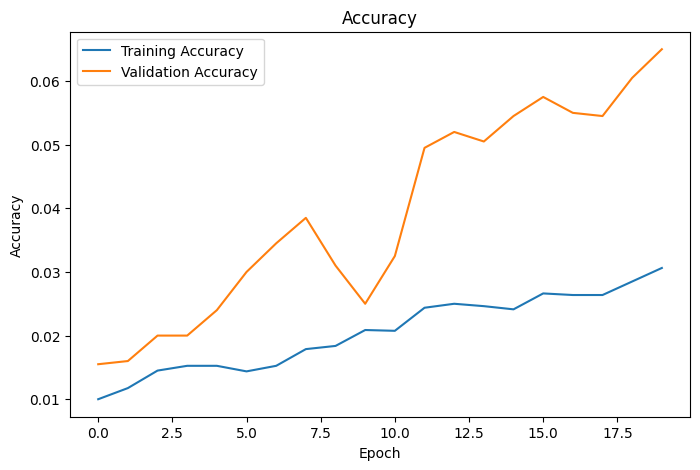

In [64]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

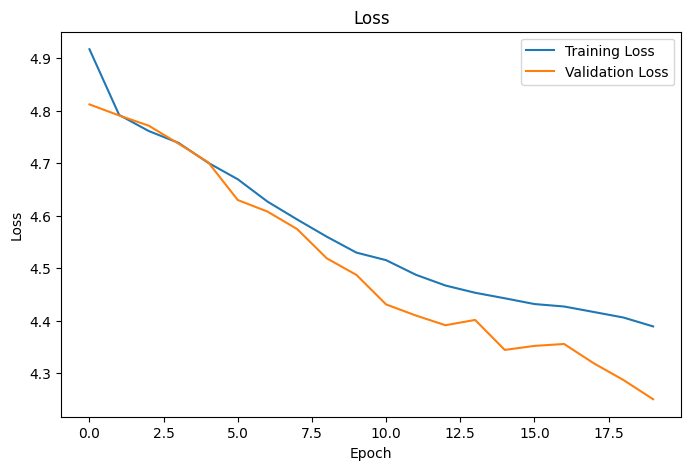

In [65]:
# Loss Plot

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Model Summary

In [66]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,950 (1.92 MB)

 Trainable params: 167,908 (655.89 KB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 335,818 (1.28 MB)

# Predefined Architecture(VGG-16)

In [67]:
# Load the model

base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(VGG_IMG_SIZE, VGG_IMG_SIZE, 3)
)

In [68]:
# Freeze pretrained convolutional layers
base_model.trainable = False

# the weights will not change during training.

In [69]:
# Building the model

vgg_model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),  # more robust than Flatten when spatial dims are tiny (e.g. 1x1 at 32px input)

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

In [70]:
# compile the model

vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
early_stop_vgg = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_vgg = tf.keras.callbacks.ModelCheckpoint(
    'best_vgg16.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [72]:
# train the model
print("Training Started...")

start_vgg = time.time()

history_vgg = vgg_model.fit(
    vgg_train_dataset,
    validation_data=vgg_test_dataset,
    epochs=40,
    callbacks=[early_stop_vgg, checkpoint_vgg]
)

end_vgg = time.time()
vgg_time = end_vgg - start_vgg
print(f"VGG16 Training Time : {vgg_time:.2f} seconds")

Training Started...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step - accuracy: 0.0251 - loss: 4.5669 - val_accuracy: 0.0790 - val_loss: 4.3878
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.0636 - loss: 4.2719 - val_accuracy: 0.1135 - val_loss: 4.0407
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.0926 - loss: 4.0270 - val_accuracy: 0.1590 - val_loss: 3.7951
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.1164 - loss: 3.8441 - val_accuracy: 0.1690 - val_loss: 3.6436
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.1332 - loss: 3.7367 - val_accuracy: 0.1890 - val_loss: 3.5406
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.1455 - loss: 3.6470 - val_accuracy: 0.2010 - val_loss: 3.4616
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.1605 - loss: 3.5638 - val_accuracy: 0.2045 - val_loss: 3.4082
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 175ms/step - accuracy: 0.1725 - los

In [73]:
# evaluate the model

test_loss, test_accuracy = vgg_model.evaluate(vgg_test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2415 - loss: 3.1057
Test Loss     : 3.1057
Test Accuracy : 24.15%


In [74]:
# save the model

vgg_model.save("vgg16_cifar100.keras")

print("Model Saved Successfully")

Model Saved Successfully


## Model summary

In [75]:
vgg_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,950,382 (57.03 MB)

 Trainable params: 78,564 (306.89 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 157,130 (613.79 KB)

# Making Predictions using the model

## Predictions Using Custom CNN

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  


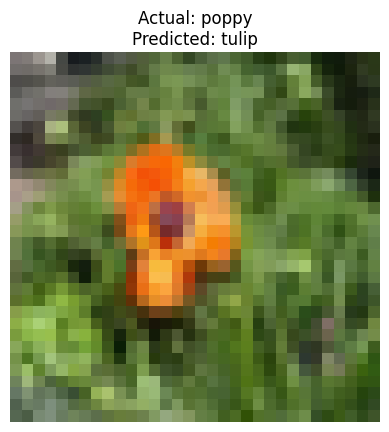

Actual Label    : poppy
Predicted Label : tulip
Confidence      : 2.37%


In [76]:
# Get one batch from the test dataset
images, labels = next(iter(test_dataset))

# Predict using the custom CNN
predictions = model.predict(images)

# Select an image
index = 0

# Get predicted and actual labels
predicted_class = np.argmax(predictions[index])
true_class = labels[index].numpy()[0]

# Display the image
plt.imshow(images[index])
plt.axis('off')
plt.title(f"Actual: {class_names[true_class]}\nPredicted: {class_names[predicted_class]}")
plt.show()

print(f"Actual Label    : {class_names[true_class]}")
print(f"Predicted Label : {class_names[predicted_class]}")
print(f"Confidence      : {np.max(predictions[index])*100:.2f}%")

## Predictions using VGG-16

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


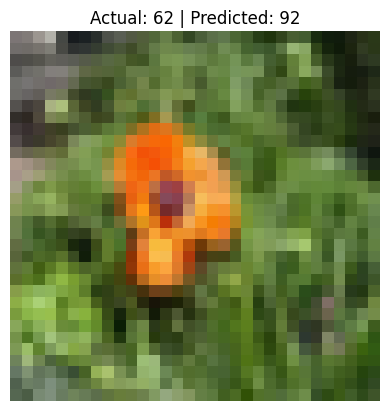

Actual Label    : 62
Predicted Label : 92
Confidence      : 15.29%


In [77]:
# Get one batch from each dataset (same underlying images/order comes from the same X_test/y_test,
# but we display the human-viewable [0,1] version and predict on the VGG-preprocessed version)
images_display, labels = next(iter(test_dataset))
images_vgg, _ = next(iter(vgg_test_dataset))

# Predict
predictions = vgg_model.predict(images_vgg)

# Select an image
index = 0

predicted_class = np.argmax(predictions[index])
true_class = labels[index].numpy()[0]

# Display image (using the displayable [0,1] version, not the mean-centered VGG input)
plt.imshow(images_display[index])
plt.axis("off")
plt.title(f"Actual: {class_names[true_class]}\nPredicted: {class_names[predicted_class]}")
plt.show()

print(f"Actual Label    : {class_names[true_class]}")
print(f"Predicted Label : {class_names[predicted_class]}")
print(f"Confidence      : {np.max(predictions[index])*100:.2f}%")

# Evaluating The model

## Custom CNN

In [78]:
# Evaluate Custom CNN

cnn_loss, cnn_accuracy = model.evaluate(test_dataset)

print("----- Custom CNN -----")
print(f"Test Loss     : {cnn_loss:.4f}")
print(f"Test Accuracy : {cnn_accuracy*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0650 - loss: 4.2502
----- Custom CNN -----
Test Loss     : 4.2502
Test Accuracy : 6.50%


## VGG-16

In [79]:
# Evaluate VGG-16

vgg_loss, vgg_accuracy = vgg_model.evaluate(vgg_test_dataset)

print("----- VGG16 -----")
print(f"Test Loss     : {vgg_loss:.4f}")
print(f"Test Accuracy : {vgg_accuracy*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2415 - loss: 3.1057
----- VGG16 -----
Test Loss     : 3.1057
Test Accuracy : 24.15%


## Comparing two models

In [80]:
print("\nModel Comparison")
print("-"*45)

print(f"{'Model':<15}{'Loss':<12}{'Accuracy'}")
print("-"*45)

print(f"{'Custom CNN':<15}{cnn_loss:<12.4f}{cnn_accuracy*100:.2f}%")
print(f"{'VGG16':<15}{vgg_loss:<12.4f}{vgg_accuracy*100:.2f}%")


Model Comparison
---------------------------------------------
Model          Loss        Accuracy
---------------------------------------------
Custom CNN     4.2502      6.50%
VGG16          3.1057      24.15%


In [81]:
# compare no of parameters
print("Custom CNN Parameters :", model.count_params())
print("VGG16 Parameters      :", vgg_model.count_params())

Custom CNN Parameters : 168132
VGG16 Parameters      : 14793252


In [82]:
# compare training time (captured live during each model's actual training run above -
# no need to retrain either model again just to measure this)
print(f"Custom CNN Training Time : {cnn_time:.2f} seconds")
print(f"VGG16 Training Time      : {vgg_time:.2f} seconds")

Epoch 1/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.0342 - loss: 4.3509 - val_accuracy: 0.0565 - val_loss: 4.2240
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.0344 - loss: 4.3518 - val_accuracy: 0.0615 - val_loss: 4.2112
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.0321 - loss: 4.3345 - val_accuracy: 0.0620 - val_loss: 4.2086
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.0347 - loss: 4.3166 - val_accuracy: 0.0720 - val_loss: 4.1769
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.0379 - loss: 4.3199 - val_accuracy: 0.0760 - val_loss: 4.1416
Custom CNN Training Time : 45.80 seconds
VGG16 Training Time      : 264.58 seconds
